# MagicAdjuster Tutorial

This notebook demonstrates how to use the `MagicAdjuster` class for statistical distribution fitting and analysis.

## Overview

`MagicAdjuster` is designed to:
- Fit statistical distributions to your data
- Perform goodness-of-fit tests (KS, Chi-square, RMSE)
- Provide seamless access to all SciPy distribution methods
- Run Monte Carlo stability analysis

## Setup and Data Generation

Let's start by importing the necessary libraries and generating some sample wind speed data.

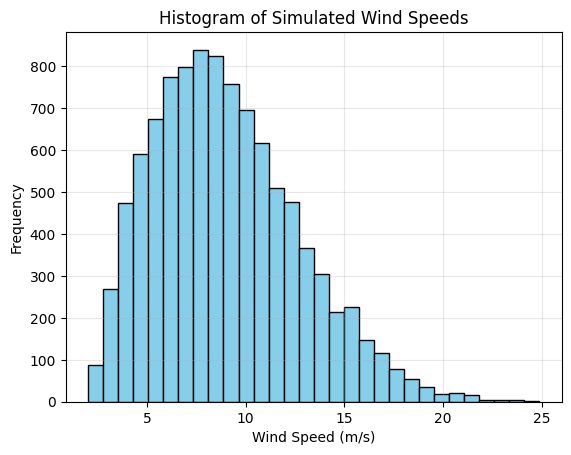

Generated 10000 wind speed measurements
Min: 2.03 m/s
Max: 24.87 m/s
Mean: 9.01 m/s
Std: 3.66 m/s


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magica as ma
from magica.core import DataProcessor, MagicAdjuster

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample wind speed data (Weibull-like distribution)
n_samples = 10000
wind_speeds = np.random.weibull(2, n_samples) * 8 + 2  # Scale and shift

# Plot histogram of wind speeds
plt.hist(wind_speeds, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Simulated Wind Speeds')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Generated {n_samples} wind speed measurements")
print(f"Min: {wind_speeds.min():.2f} m/s")
print(f"Max: {wind_speeds.max():.2f} m/s")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"Std: {wind_speeds.std():.2f} m/s")

## Basic Usage: Loading Data and Fitting a Distribution

In [2]:
# Load data using MagicA's DataProcessor
processor = ma.read_data(wind_speeds)
print(f"Loaded data: {processor}")

# Get basic statistics
stats = processor.get_basic_stats()
for key, value in stats.items():
    print(f"{key}: {value:.4f}")

Loaded data: DataProcessor(length=10000, dtype=float64)
count: 10000.0000
mean: 9.0101
std: 3.6634
var: 13.4203
min: 2.0273
max: 24.8700
median: 8.5888
q25: 6.2543
q75: 11.2852


In [3]:
# Fit a Weibull distribution (common for wind data)
fit = processor.fit('weibull_min')
print(f"Updated processor: {processor}")

# Get fitted parameters
params = fit.params
print(f"\nFitted Weibull parameters:")
print(f"Shape (c): {params[0]:.4f}")
print(f"Location (loc): {params[1]:.4f}")
print(f"Scale: {params[2]:.4f}")

# Get distribution info
info = fit.info
print(f"\nDistribution info:")
for key, value in info.items():
    print(f"{key}: {value}")

Updated processor: DataProcessor(length=10000, dtype=float64)

Fitted Weibull parameters:
Shape (c): 2.0109
Location (loc): 1.9748
Scale: 7.9409

Distribution info:
name: weibull_min
parameters: (2.0108828522203734, 1.9747913720744712, 7.940931128156867)
num_params: 3
data_size: 10000


## Accessing SciPy Methods Directly

Once a distribution is fitted, you can access all SciPy distribution methods through the returned `FitResult` (`fit`); `fit.frozen` exposes the frozen SciPy distribution.

In [4]:
# Smart defaults: evaluate at original data points
pdf_values = fit.pdf()  # PDF at all original data points
cdf_values = fit.cdf()  # CDF at all original data points

print(f"PDF values (first 10): {pdf_values[:10]}")
print(f"CDF values (first 10): {cdf_values[:10]}")

# Custom inputs also work
prob_10ms = fit.cdf(10.0)  # P(wind speed ≤ 10 m/s)
percentile_95 = fit.ppf(0.95)  # 95th percentile wind speed

print(f"\nP(wind speed ≤ 10 m/s): {prob_10ms:.4f}")
print(f"95th percentile wind speed: {percentile_95:.2f} m/s")

# Generate random samples from fitted distribution
random_samples = fit.rvs(size=5)
print(f"5 random wind speed samples: {random_samples}")

PDF values (first 10): [0.10833923 0.02040302 0.07653296 0.09622977 0.0882     0.08819511
 0.05855587 0.04647147 0.09595044 0.08076123]
CDF values (first 10): [0.38044565 0.95426667 0.73969983 0.60636965 0.15898947 0.15896499
 0.05952766 0.87233822 0.60883529 0.71586528]

P(wind speed ≤ 10 m/s): 0.6399
95th percentile wind speed: 15.68 m/s
5 random wind speed samples: [7.41742125 7.03970835 5.48590614 9.65316876 8.37195175]


## Goodness-of-Fit Testing

Evaluate how well the distribution fits your data using various statistical tests.

In [5]:
# Kolmogorov-Smirnov test
ks_result = fit.goodness_of_fit('ks')
print("Kolmogorov-Smirnov Test:")
print(f"  Statistic: {ks_result['ks_statistic']:.6f}")
print(f"  P-value: {ks_result['p_value']:.6f}")
ks_decision = 'Do not reject the fitted model' if ks_result['p_value'] > 0.05 else 'Reject the fitted model'
print(f"  Decision at α = 0.05: {ks_decision}")

# Chi-square test
chi2_result = fit.goodness_of_fit('chi2')
print("\nChi-square Test:")
print(f"  Statistic: {chi2_result['chi2_statistic']:.6f}")
print(f"  P-value: {chi2_result['p_value']:.6f}")
print(f"  Bins used: {chi2_result['n_bins']}")
chi2_decision = 'Do not reject the fitted model' if chi2_result['p_value'] > 0.05 else 'Reject the fitted model'
print(f"  Decision at α = 0.05: {chi2_decision}")

# RMSE
rmse = fit.goodness_of_fit('rmse')
print(f"\nRoot Mean Square Error: {rmse:.6f}")

Kolmogorov-Smirnov Test:
  Statistic: 0.005025
  P-value: 0.961225
  Decision at α = 0.05: Do not reject the fitted model

Chi-square Test:
  Statistic: 13.724140
  P-value: 0.746889
  Bins used: 19
  Decision at α = 0.05: Do not reject the fitted model

Root Mean Square Error: 0.001775


/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 9997.357954, Target sum: 10000
  warnings.warn(


### Understanding Chi-square Test and Number of Bins

The chi-square goodness-of-fit test compares observed frequencies in histogram bins with expected frequencies from the fitted distribution. The number of bins significantly affects the test results.

In [6]:
# Demonstrate different binning methods for chi-square test
binning_methods = ['doane', 'sturges', 'freedman-diaconis', 'rice', 'scott', 30]

print("Chi-square Test Results with Different Binning Methods:")
print("-" * 70)
print(f"{'Method':<20} {'Bins':<6} {'Chi2 Stat':<12} {'P-value':<12} {'Decision'}")
print("-" * 70)

for method in binning_methods:
    chi2_result = fit.goodness_of_fit('chi2', bins=method)
    result_text = 'Do not reject' if chi2_result['p_value'] > 0.05 else 'Reject'
    method_name = str(method) if isinstance(method, int) else method
    
    print(f"{method_name:<20} {chi2_result['n_bins']:<6} {chi2_result['chi2_statistic']:<12.4f} "
          f"{chi2_result['p_value']:<12.6f} {result_text}")

print("\nBinning Method Guidelines:")
print("- Doane: Adjusts Sturges' rule for sample skewness (default)")
print("- Sturges: Uses a logarithmic rule for the bin count")
print("- Freedman-Diaconis: Uses the interquartile range and sample size")
print("- Rice: Simple rule, scales with cube root of sample size")
print("- Scott: Minimizes integrated mean square error")
print("- Fixed number: Use when you need specific bin count")

Chi-square Test Results with Different Binning Methods:
----------------------------------------------------------------------
Method               Bins   Chi2 Stat    P-value      Decision
----------------------------------------------------------------------
doane                19     13.7241      0.746889     Do not reject
sturges              14     9.7122       0.717285     Do not reject
freedman-diaconis    48     39.3616      0.777948     Do not reject
rice                 43     40.2136      0.549608     Do not reject
scott                38     31.4205      0.727675     Do not reject
30                   30     29.8675      0.420640     Do not reject

Binning Method Guidelines:
- Doane: Adjusts Sturges' rule for sample skewness (default)
- Sturges: Uses a logarithmic rule for the bin count
- Freedman-Diaconis: Uses the interquartile range and sample size
- Rice: Simple rule, scales with cube root of sample size
- Scott: Minimizes integrated mean square error
- Fixed number: U

## Visualization: Comparing Data and Fitted Distribution

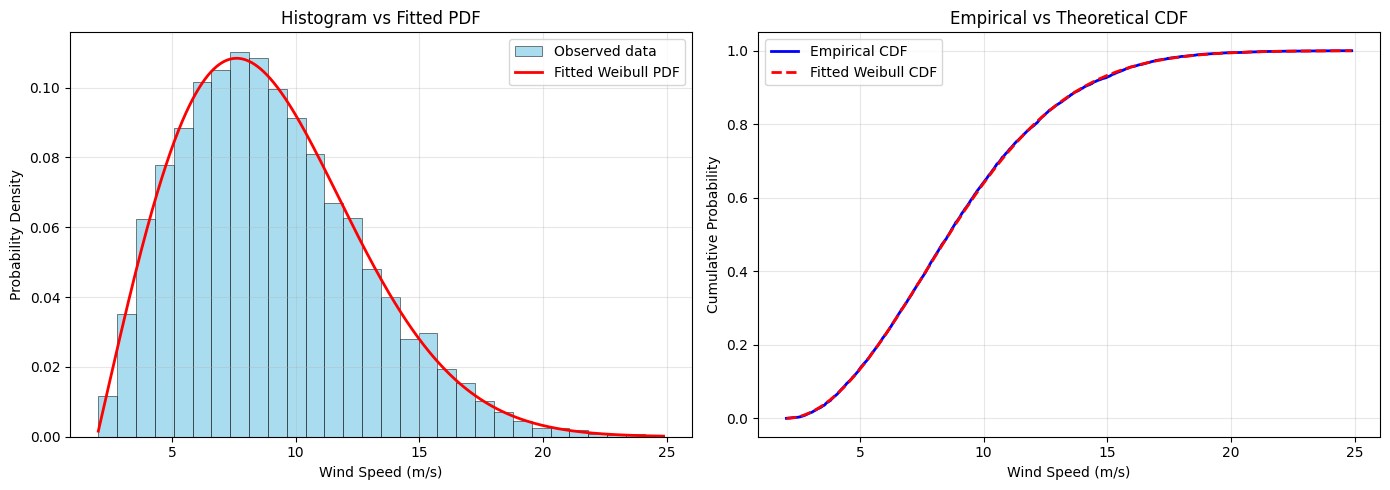

In [7]:
# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram with fitted PDF
ax1.hist(wind_speeds, bins=30, density=True, alpha=0.7, color='skyblue', 
         label='Observed data', edgecolor='black', linewidth=0.5)

# Generate smooth curve for fitted distribution
x_smooth = np.linspace(wind_speeds.min(), wind_speeds.max(), 1000)
pdf_smooth = fit.pdf(x_smooth)
ax1.plot(x_smooth, pdf_smooth, 'r-', linewidth=2, label='Fitted Weibull PDF')

ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Histogram vs Fitted PDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Empirical vs Theoretical CDF
sorted_data = np.sort(wind_speeds)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = fit.cdf(sorted_data)

ax2.plot(sorted_data, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax2.plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Fitted Weibull CDF')

ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Empirical vs Theoretical CDF')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Using Different Distributions

Let's try fitting other distributions to see which one works best.

In [8]:
# Test different distributions
distributions_to_test = ['weibull_min', 'lognorm', 'gamma', 'norm', 'expon']
results = []

for dist_name in distributions_to_test:
    # Create a fresh processor for each distribution
    temp_processor = ma.read_data(wind_speeds)
    temp_fit = temp_processor.fit(dist_name)
    
    # Calculate goodness-of-fit metrics
    ks_test = temp_fit.goodness_of_fit('ks')
    rmse = temp_fit.goodness_of_fit('rmse')
    
    results.append({
        'distribution': dist_name,
        'ks_pvalue': ks_test['p_value'],
        'rmse': rmse,
        'parameters': temp_fit.params
    })

# Display results
print("Distribution Comparison:")
print("-" * 60)
print(f"{'Distribution':<15} {'KS p-value':<12} {'RMSE':<10} {'Fit Quality'}")
print("-" * 60)

for result in results:
    quality = "Good" if result['ks_pvalue'] > 0.05 else "Poor"
    print(f"{result['distribution']:<15} {result['ks_pvalue']:<12.6f} {result['rmse']:<10.6f} {quality}")

# Find best distribution (highest KS p-value)
best_result = max(results, key=lambda x: x['ks_pvalue'])
print(f"\nBest distribution: {best_result['distribution']} (KS p-value: {best_result['ks_pvalue']:.6f})")

Distribution Comparison:
------------------------------------------------------------
Distribution    KS p-value   RMSE       Fit Quality
------------------------------------------------------------
weibull_min     0.961225     0.001775   Good
lognorm         0.007746     0.010314   Poor
gamma           0.020087     0.009206   Poor
norm            0.000000     0.029975   Poor
expon           0.000000     0.134458   Poor

Best distribution: weibull_min (KS p-value: 0.961225)


## Advanced Usage: Distribution Parameters with Constraints

You can constrain distribution parameters during fitting (e.g., fix location parameter).

In [9]:
# Fit Weibull with fixed location parameter (floc=0)
processor_constrained = ma.read_data(wind_speeds)
fit_constrained = processor_constrained.fit('weibull_min', floc=0)  # Fix location to 0

params_constrained = fit_constrained.params
print("Weibull with floc=0:")
print(f"Shape (c): {params_constrained[0]:.4f}")
print(f"Location (fixed): {params_constrained[1]:.4f}")
print(f"Scale: {params_constrained[2]:.4f}")

# Compare with unconstrained fit
params_unconstrained = fit.params
print("\nUnconstrained Weibull:")
print(f"Shape (c): {params_unconstrained[0]:.4f}")
print(f"Location: {params_unconstrained[1]:.4f}")
print(f"Scale: {params_unconstrained[2]:.4f}")

# Compare goodness of fit
ks_constrained = fit_constrained.goodness_of_fit('ks')
ks_unconstrained = fit.goodness_of_fit('ks')

print(f"\nGoodness of fit comparison:")
print(f"Constrained KS p-value: {ks_constrained['p_value']:.6f}")
print(f"Unconstrained KS p-value: {ks_unconstrained['p_value']:.6f}")

Weibull with floc=0:
Shape (c): 2.6326
Location (fixed): 0.0000
Scale: 10.1575

Unconstrained Weibull:
Shape (c): 2.0109
Location: 1.9748
Scale: 7.9409

Goodness of fit comparison:
Constrained KS p-value: 0.000000
Unconstrained KS p-value: 0.961225


## Monte Carlo Stability Analysis

Examine how parameter estimates and goodness-of-fit diagnostics vary across a selected grid of sample sizes.

## Large Sample Size Effect and Monte Carlo CPS Method

### The Problem with Large Datasets

As sample size grows, statistical tests gain power and may produce very small p-values for departures that are negligible in practice. There is no universal sample-size cutoff for this effect.

Let's demonstrate this problem and show how the Monte Carlo CPS (Coefficient/P-value/Sample size) method can help.

In [10]:
# Generate large synthetic dataset for demonstrating large sample size effect
print("Generating large synthetic dataset for demonstration...")
print("(This simulates the 'large sample size effect' with synthetic data)\n")

# Generate 10 years of hourly data (87,600 samples)
from magica.utils import generate_wind_data

wind_speeds_large = generate_wind_data(
    n_years=10,
    freq='h',  # Hourly data
    mean_wind=8.0,
    weibull_shape=2.0,
    seasonal_amplitude=0.3,
    n_storms_per_year=5,
    storm_duration_range=(12, 48),  # 12-48 hour storms
    storm_intensity_range=(15, 25),
    random_seed=42
)

# Convert Series to array
wind_speeds_real = wind_speeds_large.values
large_sample_size = len(wind_speeds_real)

print(f"Generated synthetic dataset: {large_sample_size:,} samples")
print(f"Mean: {wind_speeds_real.mean():.2f} m/s")
print(f"Std: {wind_speeds_real.std():.2f} m/s")

# Fit Weibull distribution to large dataset
large_processor = ma.read_data(wind_speeds_real)
large_adjuster = MagicAdjuster(large_processor)
large_fit = large_adjuster.fit_distribution('weibull_min')

# Compare goodness-of-fit tests between small and large datasets
print("\n" + "="*60)
print("COMPARISON: Small vs Large Dataset")
print("="*60)

Generating large synthetic dataset for demonstration...
(This simulates the 'large sample size effect' with synthetic data)

Generated synthetic dataset: 87,625 samples
Mean: 7.62 m/s
Std: 3.52 m/s

COMPARISON: Small vs Large Dataset


### The Monte Carlo CPS Solution

The Monte Carlo CPS method addresses this by:

1. **Testing multiple subsample sizes** to understand how fit quality evolves
2. **Using CDF RMSE as the primary stability signal**, following MagicA's empirical results
3. **Detecting a configured stability point** when the selected rule finds one
4. **Reporting diagnostic values** at the detected point

**What RMSE contributes:**
- Directly summarizes distance between the empirical and fitted CDFs
- Produced a clearer stability point than the p-value curves in the analyses that motivated MagicA
- Uses test statistics and p-values as complementary diagnostics
- Does not penalize model complexity or specifically emphasize the tails

Let's run a comprehensive analysis focused on RMSE stability:

Running Monte Carlo CPS Analysis on Large Dataset...
This will take a moment as we test multiple subsample sizes...



/Users/danilocoutodesouza/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7400: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp


✓ Monte Carlo CPS analysis completed!
Results dimensions: {'sizes': 10, 'repeats': 50}
Available variables: ['param_0', 'param_1', 'param_2', 'ks_statistic', 'ks_pvalue', 'chi2_statistic', 'chi2_pvalue', 'rmse']
Figure saved to: cps_analysis.png

⭐ STABILITY ANALYSIS RESULTS (RMSE-Focused)
✓ RMSE stabilizes at n = 400 (RECOMMENDED)
  Detection method: Kneedle algorithm
  RMSE at stable point: 0.021654
  KS p-value at stable point: 0.4281

Other metrics (for reference only):
  param_0: n = 400
  param_2: n = 600
  ks_pvalue: n = 800
  chi2_pvalue: n = 400

💡 FOCUS ON RMSE:
  • RMSE is the empirically recommended primary stability signal
  • Kneedle identifies a geometric bend in the summarized curve
  • Other metrics answer complementary questions
  • Check sensitivity before using n = 400 in the application


/var/folders/4_/b_fgl21s1r71g9xz3dytgnbr0000gn/T/ipykernel_5083/1529751161.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Results dimensions: {dict(mc_results.dims)}")


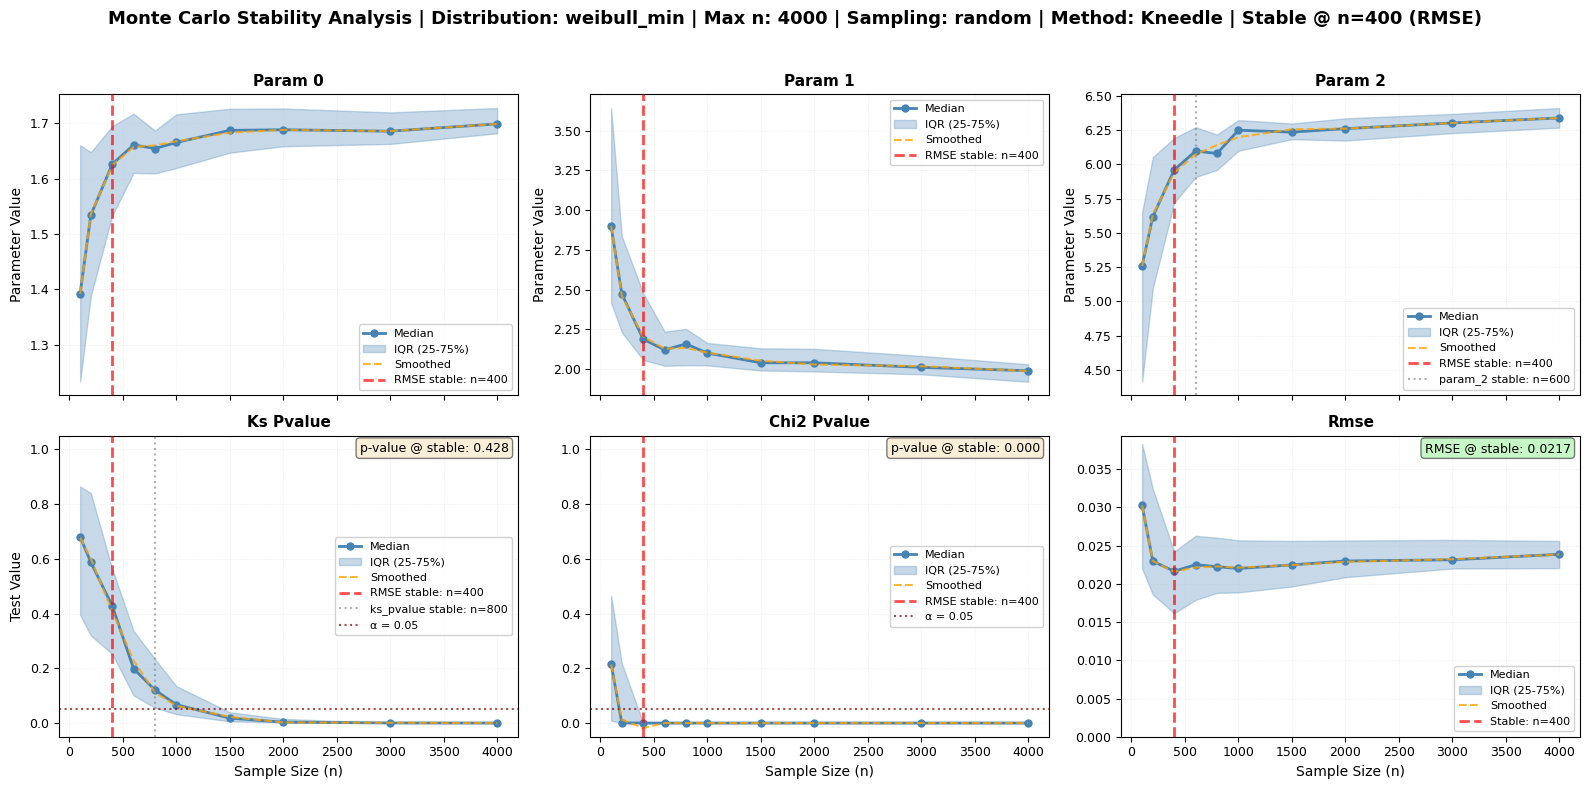

In [11]:
# Run comprehensive Monte Carlo CPS analysis with RMSE-focused stability detection
print("Running Monte Carlo CPS Analysis on Large Dataset...")
print("This will take a moment as we test multiple subsample sizes...\n")

# Define the sample sizes to test (from small to large)
test_sizes = [100, 200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000]

# ⭐ KEY CONFIGURATION: Use Kneedle method for RMSE stability detection
# Use Kneedle to locate a bend in the summarized RMSE curve
mc_results = large_adjuster.monte_carlo_fit(
    sizes=test_sizes,                    # Sample sizes to test
    n_repeats=50,                        # Number of subsamples per size
    tests=['ks', 'chi2', 'rmse'],        # Compare tests with CDF distance
    stability_method='kneedle',          # Detect bends in summarized curves
    smooth=True,                         # Smooth curves for clearer elbow detection
    sampling='random',                   # Sampling strategy
    seed=42,                             # For reproducibility
    fig_output_path='cps_analysis.png',  # Auto-generate figure with RMSE focus
    plot_type='series'                   # Series plot style
)

print("✓ Monte Carlo CPS analysis completed!")
print(f"Results dimensions: {dict(mc_results.dims)}")
print(f"Available variables: {list(mc_results.data_vars.keys())}")
print(f"Figure saved to: {mc_results.attrs['figure_path']}")

# Inspect the primary result and its metric
recommended_n = mc_results.attrs['recommended_size']
primary_metric = mc_results.attrs['primary_metric']

print(f"\n{'='*60}")
print("⭐ STABILITY ANALYSIS RESULTS (RMSE-Focused)")
print("="*60)

if recommended_n is not None:
    if primary_metric == 'max_size':
        print(f"No stability detected; largest tested size = {recommended_n}")
    else:
        print(f"✓ {primary_metric.upper()} stability detected at n = {recommended_n}")
    print(f"  Detection method: Kneedle algorithm")
    
    # Show quality metrics at the stable point
    if mc_results.attrs.get('stable_rmse') is not None:
        print(f"  RMSE at stable point: {mc_results.attrs['stable_rmse']:.6f}")
    if mc_results.attrs.get('stable_pvalue_ks') is not None:
        print(f"  KS p-value at stable point: {mc_results.attrs['stable_pvalue_ks']:.4f}")
else:
    print(f"○ {primary_metric.upper()}: no clear stability detected")

# Show other stability points as examples (not the focus)
print(f"\nOther metrics (for reference only):")
stability_info = mc_results.attrs['stability_points']
for param in ['param_0', 'param_2', 'ks_pvalue', 'chi2_pvalue']:
    if param in stability_info:
        info = stability_info[param]
        size = info.get('size', 'Not detected')
        print(f"  {param}: n = {size}")

print(f"\n{'='*60}")
print("💡 INTERPRETATION:")
print("  • RMSE is the empirically recommended primary stability signal")
print("  • Kneedle identifies a geometric bend in the summarized curve")
print("  • Other metrics answer complementary questions")
print(f"  • Check sensitivity before using n = {recommended_n} in the application")

In [12]:
# Display key results
recommended_n = mc_results.attrs['recommended_size']
primary_metric = mc_results.attrs['primary_metric']

print(f"\n{'='*60}")
print(f"Primary stability result: n = {recommended_n}")
print(f"Based on: {primary_metric.upper()}")

if mc_results.attrs.get('stable_rmse') is not None:
    print(f"\nQuality at stable point:")
    print(f"  RMSE: {mc_results.attrs['stable_rmse']:.6f}")
if mc_results.attrs.get('stable_pvalue_ks') is not None:
    print(f"  KS p-value: {mc_results.attrs['stable_pvalue_ks']:.4f}")
print(f"{'='*60}")


Primary stability result: n = 400
Based on: RMSE

Quality at stable point:
  RMSE: 0.021654
  KS p-value: 0.4281


### 📊 Interpreting the CPS Analysis Figure

⭐ Primary Focus: RMSE Panel (Bottom Right)

The RMSE panel shows MagicA's empirically recommended primary stability signal:
- Orange dashed line: Smoothed RMSE curve showing convergence pattern
- **Red vertical line**: Stability point detected by the configured method
- **Pattern**: Inspect whether the summarized curve has a meaningful bend or plateau

**Other Panels** (shown for completeness):
- **Top row**: Parameter convergence (shape, scale, location)
- **Bottom left/center**: Statistical test p-values, interpreted with their assumptions

**Key Takeaway**: Use the RMSE result as the primary stability indication, compare it with parameters and test outputs, and check sensitivity to the tested grid, repeats, and detector settings.

### Monte Carlo Sampling Strategies

The `monte_carlo_fit` method offers different sampling strategies. MagicA recommends **RMSE stability detection** as the primary indicator because it produced a clearer stability point than the p-value curves in the empirical tests that motivated the method:

Comparing Monte Carlo Sampling Strategies (RMSE-Focused):
NOTE: Using reduced parameters for demonstration (faster execution)
      Using RMSE as MagicA's empirically recommended primary stability indicator


Testing 'random' sampling...
  ⭐ RMSE stability: n = 1500 (PRIMARY)
  • Shape parameter: n = 1500 (example)
  Figure saved to: mc_sampling_random.png
  ✓ Completed

Testing 'bootstrap' sampling...
  ⭐ RMSE stability: n = 1000 (PRIMARY)
  • Shape parameter: n = 1500 (example)
  Figure saved to: mc_sampling_bootstrap.png
  ✓ Completed

Testing 'disjoint' sampling...
  ⭐ RMSE stability: n = 1000 (PRIMARY)
  • Shape parameter: n = 2500 (example)
  Figure saved to: mc_sampling_disjoint.png
  ✓ Completed

SAMPLING STRATEGY GUIDE:
🎲 RANDOM sampling:
   • Most common approach
   • Each subsample is independently drawn without replacement
   • Useful for repeated draws without duplicates within each draw
   • Variability depends on the data and sample-size grid

🔄 BOOTSTRAP sampling:
   • 

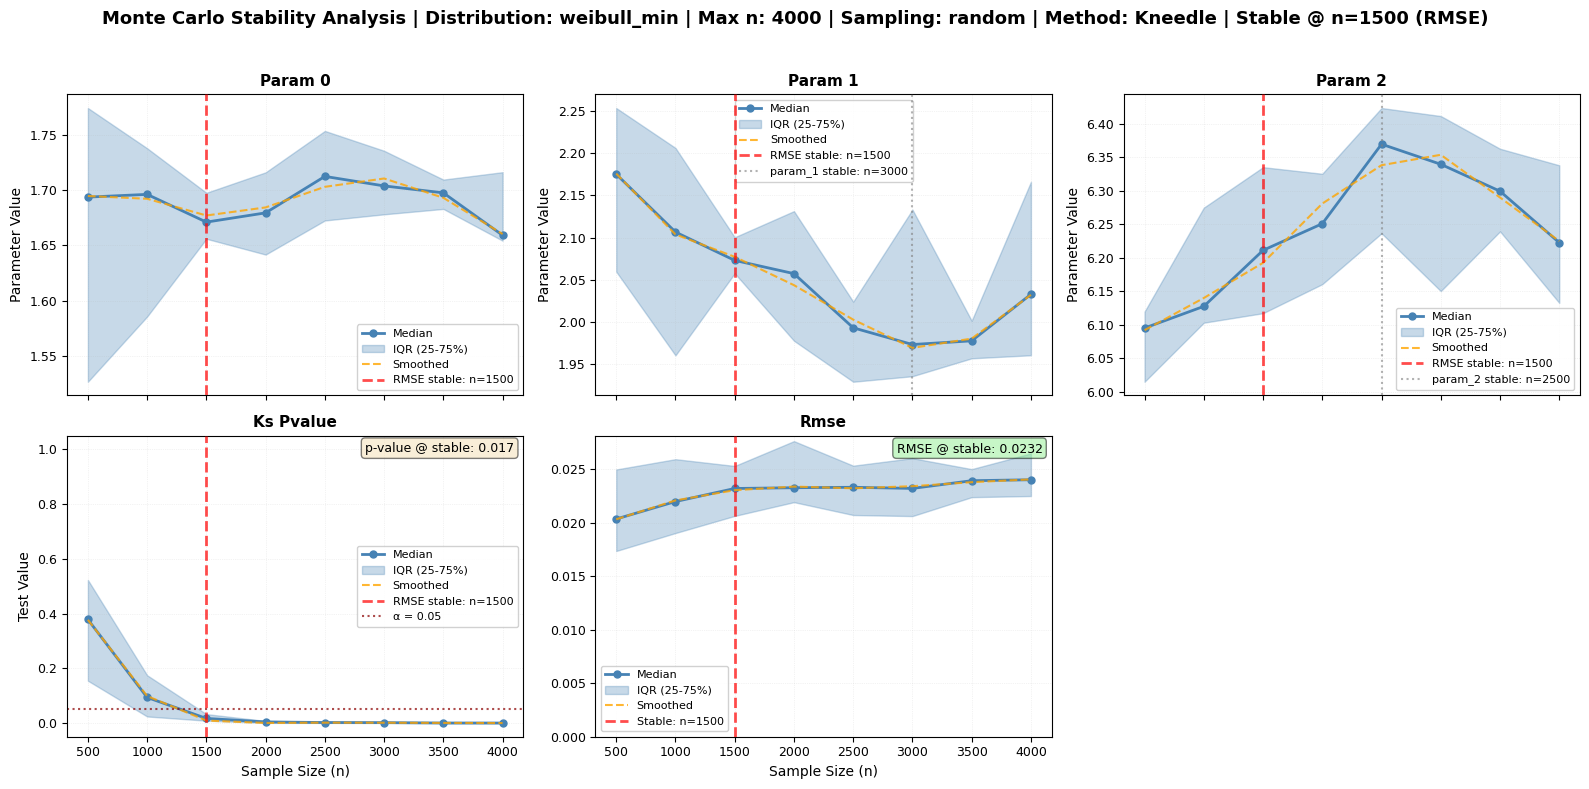

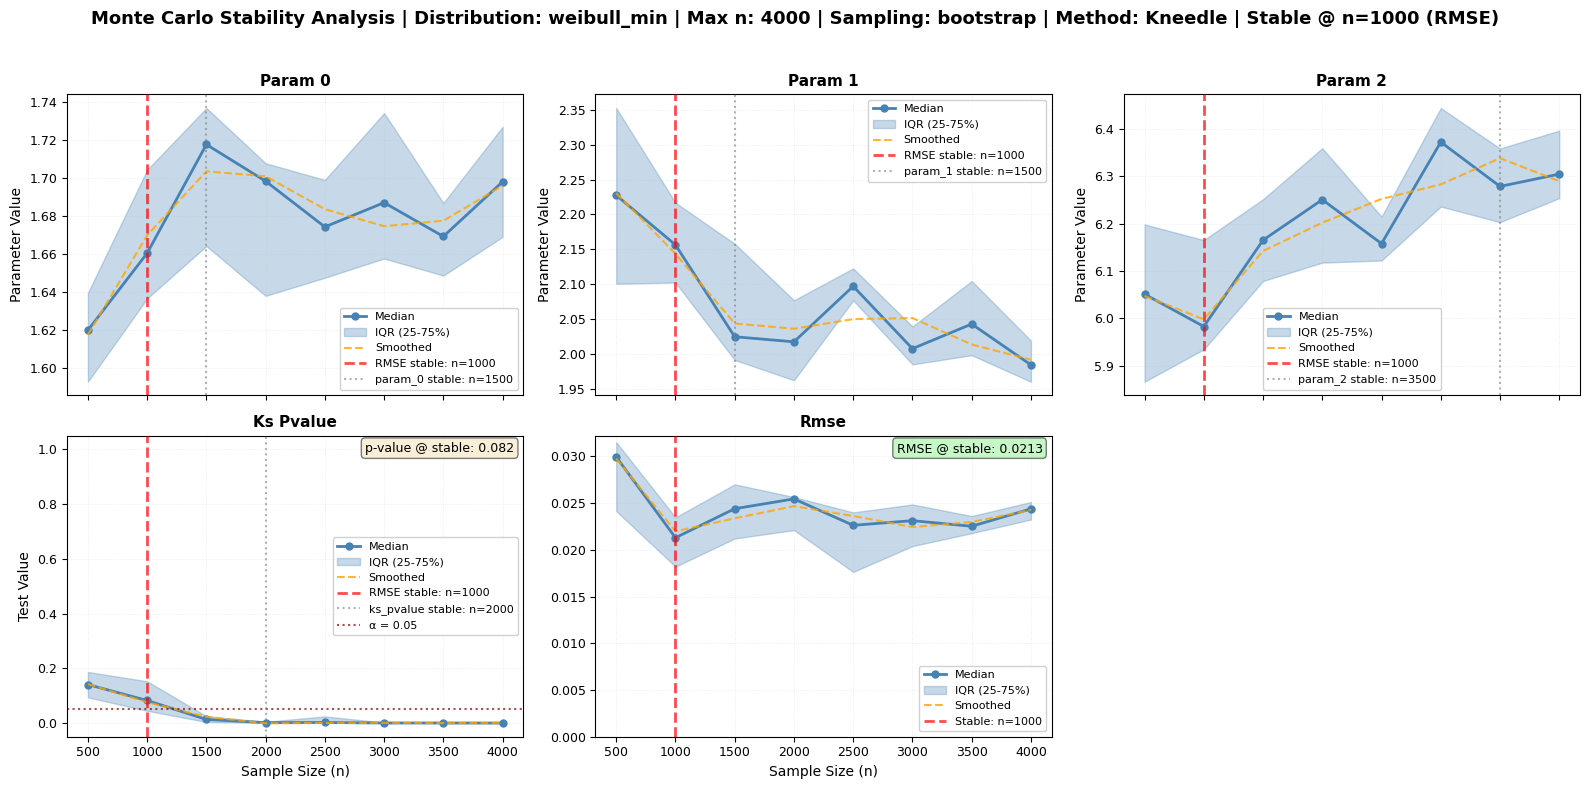

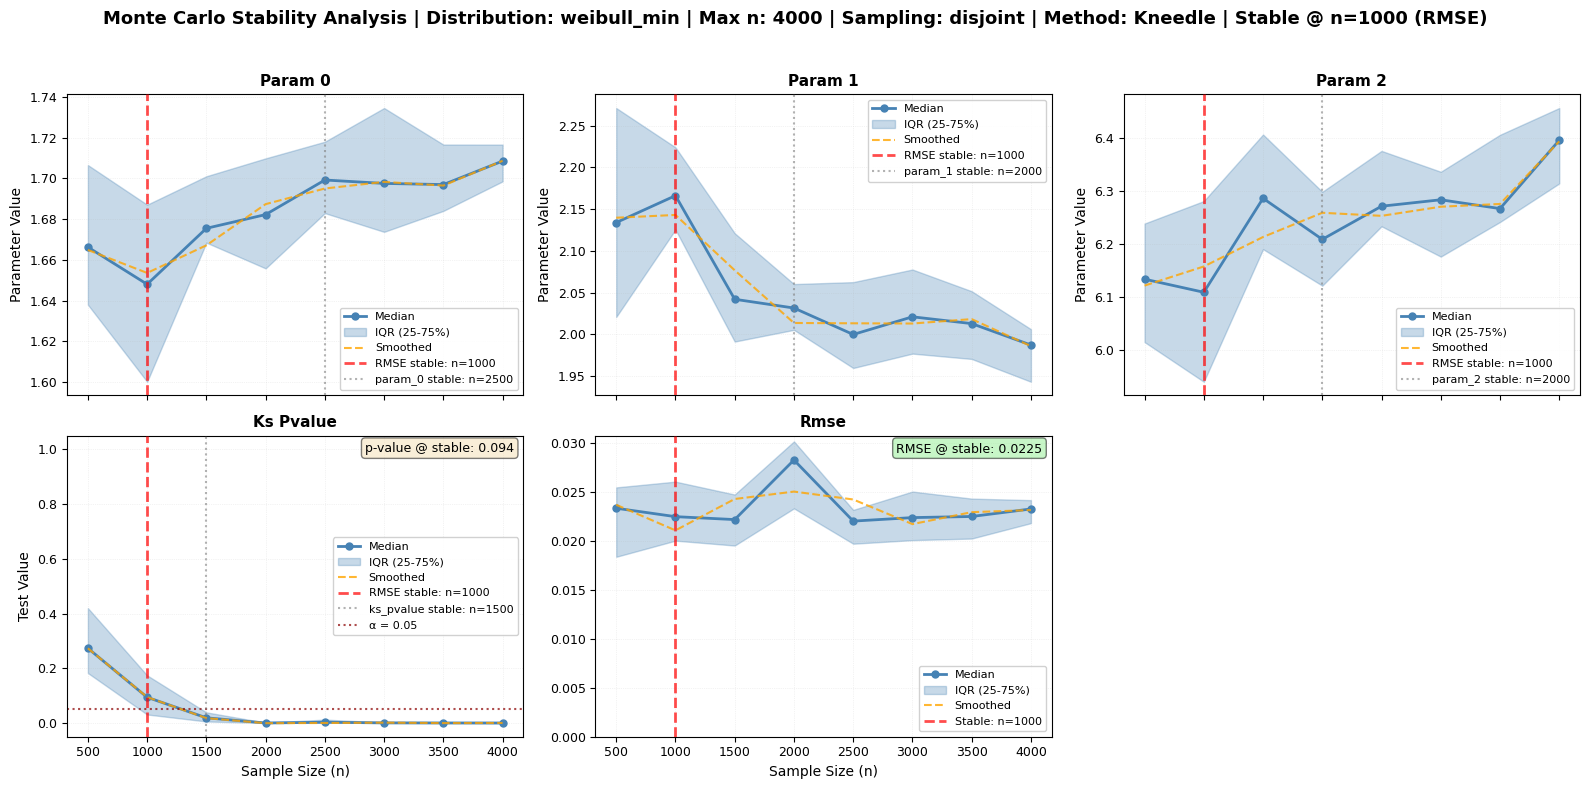

In [13]:
# Compare different sampling strategies with RMSE-focused stability detection
# Using smaller sizes and fewer repeats for demonstration purposes
sampling_strategies = ['random', 'bootstrap', 'disjoint']
strategy_results = {}

print("Comparing Monte Carlo Sampling Strategies (RMSE-Focused):")
print("=" * 60)
print("NOTE: Using reduced parameters for demonstration (faster execution)")
print("      Using RMSE as MagicA's empirically recommended primary stability indicator")
print("")

for i, strategy in enumerate(sampling_strategies):
    print(f"\nTesting '{strategy}' sampling...")
    
    # Run analysis with Kneedle method for RMSE stability
    fig_path = f'mc_sampling_{strategy}.png'
    
    mc_strategy = large_adjuster.monte_carlo_fit(
        sizes=[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000],
        n_repeats=10,  # Reduced for speed
        tests=['ks', 'rmse'],          # Focus on RMSE
        stability_method='kneedle',    # Detect a bend in summarized curves
        smooth=True,                   # Smooth for clear elbow
        sampling=strategy,
        seed=42,
        fig_output_path=fig_path,
        plot_type='series'
    )
    
    strategy_results[strategy] = mc_strategy
    
    # Get recommended size (based on RMSE)
    recommended_n = mc_strategy.attrs.get('recommended_size', 'Not detected')
    primary_metric = mc_strategy.attrs.get('primary_metric', 'rmse')
    
    print(f"  ⭐ {primary_metric.upper()} stability: n = {recommended_n} (PRIMARY)")
    
    # Show parameters as examples only
    stability = mc_strategy.attrs['stability_points']
    if 'param_0' in stability:
        param_0_size = stability['param_0'].get('size', 'Not detected')
        print(f"  • Shape parameter: n = {param_0_size} (example)")
    
    print(f"  Figure saved to: {mc_strategy.attrs['figure_path']}")
    print(f"  ✓ Completed")

print("\n" + "="*60)
print("SAMPLING STRATEGY GUIDE:")
print("="*60)
print("🎲 RANDOM sampling:")
print("   • Most common approach")
print("   • Each subsample is independently drawn without replacement")
print("   • Useful for repeated draws without duplicates within each draw")
print("   • Variability depends on the data and sample-size grid")
print("")
print("🔄 BOOTSTRAP sampling:")
print("   • Samples with replacement")
print("   • Can be used to explore sampling variability")
print("   • Interval interpretation depends on the bootstrap assumptions")
print("   • Allows subsample size > original data size")
print("")
print("📐 DISJOINT sampling (use sampling='disjoint'):")
print("   • Creates non-overlapping partitions")
print("   • No overlap within each shuffle; additional shuffles can reuse points")
print("   • Shuffles data; does not preserve temporal/spatial order")
print("")
print("💡 GUIDANCE:")
print("   Use 'random' for repeated draws, 'bootstrap' for replacement-based resampling,")
print("   or 'disjoint' for non-overlapping partitions within each shuffle.")
print("")
print("⭐ REMEMBER:")
print("   • RMSE is the empirically recommended primary stability indicator")
print("   • Look at the RMSE panel (rightmost) in the figures")
print("   • Parameter stability shown as examples, not the focus")
print("")
print("⚡ SENSITIVITY CHECK:")
print("   Increase n_repeats and refine the sample-size grid to check whether the result changes.")
print("   This demo uses reduced settings for faster execution.")

# Display comparison summary
print("\n" + "="*60)
print("Generated figures comparing sampling strategies:")
print("⭐ Focus on RMSE panel (bottom right) in each figure")
for strategy, results in strategy_results.items():
    recommended = results.attrs.get('recommended_size', 'N/A')
    print(f"  - {strategy}: n = {recommended} | {results.attrs['figure_path']}")

### Practical Application: Inspecting an RMSE Stability Point

The next example uses the RMSE stability point detected in this configured run. Treat it as an empirical result of the selected grid and detector, not as a universal optimum:

In [14]:
# Use the detected point for an illustrative follow-up comparison
detected_size = mc_results.attrs['recommended_size']

print(f"Using the detected RMSE stability point: n = {detected_size}")
print("   (Determined by Kneedle algorithm on RMSE convergence)")
print("\nCreating multiple disjoint subsamples for comparison...\n")

# Create multiple disjoint subsamples at the detected size
n_subsamples = min(5, len(wind_speeds_real) // detected_size)
subsample_results = []

np.random.seed(42)  # For reproducible subsampling
shuffled_data = wind_speeds_real.copy()
np.random.shuffle(shuffled_data)

for i in range(n_subsamples):
    start_idx = i * detected_size
    end_idx = (i + 1) * detected_size
    subsample = shuffled_data[start_idx:end_idx]
    
    # Fit distribution to subsample
    sub_processor = ma.read_data(subsample)
    sub_fit = sub_processor.fit('weibull_min')
    
    # Get parameters and goodness-of-fit
    params = sub_fit.params
    ks_test = sub_fit.goodness_of_fit('ks')
    chi2_test = sub_fit.goodness_of_fit('chi2')
    rmse_value = sub_fit.goodness_of_fit('rmse')
    
    subsample_results.append({
        'subsample': i + 1,
        'size': len(subsample),
        'shape_c': params[0],
        'location': params[1], 
        'scale': params[2],
        'rmse': rmse_value,
        'ks_pvalue': ks_test['p_value'],
        'chi2_pvalue': chi2_test['p_value']
    })

# Display results
print("Subsample Comparison at the Detected RMSE Stability Point:")
print("=" * 90)
print(f"{'Sub':<4} {'Size':<6} {'Shape(c)':<10} {'Location':<10} {'Scale':<10} {'RMSE':<10} {'KS p-val':<10} {'Chi2 p-val'}")
print("-" * 90)

for result in subsample_results:
    print(f"{result['subsample']:<4} {result['size']:<6} {result['shape_c']:<10.4f} "
          f"{result['location']:<10.4f} {result['scale']:<10.4f} "
          f"{result['rmse']:<10.6f} {result['ks_pvalue']:<10.4f} {result['chi2_pvalue']:<10.4f}")

# Calculate empirical statistics
shape_values = [r['shape_c'] for r in subsample_results]
scale_values = [r['scale'] for r in subsample_results]
rmse_values = [r['rmse'] for r in subsample_results]
ks_pvalues = [r['ks_pvalue'] for r in subsample_results]

print(f"\nEmpirical Distribution Summary:")
print(f"Shape parameter (c):")
print(f"  Mean ± Std: {np.mean(shape_values):.4f} ± {np.std(shape_values):.4f}")
print(f"  Range: [{np.min(shape_values):.4f}, {np.max(shape_values):.4f}]")
print(f"Scale parameter:")
print(f"  Mean ± Std: {np.mean(scale_values):.4f} ± {np.std(scale_values):.4f}")
print(f"  Range: [{np.min(scale_values):.4f}, {np.max(scale_values):.4f}]")
print(f"RMSE values:")
print(f"  Mean ± Std: {np.mean(rmse_values):.6f} ± {np.std(rmse_values):.6f}")
print(f"  Range: [{np.min(rmse_values):.6f}, {np.max(rmse_values):.6f}]")
print(f"  Relative SD below illustrative 0.1 threshold: {np.std(rmse_values) / np.mean(rmse_values) < 0.1}")
print(f"KS p-values:")
print(f"  Mean ± Std: {np.mean(ks_pvalues):.4f} ± {np.std(ks_pvalues):.4f}")
print(f"  All p-values > 0.05: {all(p > 0.05 for p in ks_pvalues)}")

print(f"\nResults at the detected size (n = {detected_size}):")
print(f"   • Compare RMSE variation across subsamples")
print(f"   • Inspect parameter variability")
print(f"   • Interpret p-values with their assumptions and calibration")
print(f"   • These repetitions describe this sampling run; they are not automatically calibrated confidence intervals")
print(f"   • Assess practical significance against domain criteria")
print(f"\n💡 KEY INSIGHT:")
print(f"   RMSE-based stability detection returned n = {detected_size}")
print(f"   This point is conditional on the configured grid and detector.")

Using the detected RMSE stability point: n = 400
   (Determined by Kneedle algorithm on RMSE convergence)

Creating multiple disjoint subsamples for comparison...

Subsample Comparison at the Detected RMSE Stability Point:
Sub  Size   Shape(c)   Location   Scale      RMSE       KS p-val   Chi2 p-val
------------------------------------------------------------------------------------------
1    400    1.7053     2.0189     6.1542     0.031209   0.1705     0.0000    
2    400    1.6078     2.0696     6.5209     0.026880   0.1978     0.0000    
3    400    0.8002     2.0431     3.1136     0.276048   0.0000     0.0000    
4    400    1.6991     2.1394     5.9243     0.027703   0.2169     0.0000    
5    400    1.5617     2.4421     5.8768     0.027286   0.2882     0.0000    

Empirical Distribution Summary:
Shape parameter (c):
  Mean ± Std: 1.4748 ± 0.3417
  Range: [0.8002, 1.7053]
Scale parameter:
  Mean ± Std: 5.5179 ± 1.2235
  Range: [3.1136, 6.5209]
RMSE values:
  Mean ± Std: 0.077825

/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 399.934636, Target sum: 400
  warnings.warn(
/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 399.833451, Target sum: 400
  warnings.warn(
/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 399.858784, Target sum: 400
  warnings.warn(
/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 399.924949, Target sum: 400
  warnings.warn(
/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:199: UserWarning: Normalizing expected frequencies. Original sum: 399.901781, Target s

## Comparing Stability Detection Methods

The `monte_carlo_fit()` method supports multiple algorithms for detecting when parameters and goodness-of-fit metrics stabilize. Each method has strengths for different types of metrics. Let's explore them!

### Available Methods:

1. **CV (Coefficient of Variation)** - Variability-based detection
2. **Kneedle Algorithm** - Default; for decreasing metrics (RMSE) and converging parameters
3. **Plateau Detection** - Good for metrics with clear convergence behavior

Let's compare these methods using our large dataset.

Comparing Stability Detection Methods
Running Monte Carlo analysis with different detection methods...
This will take a moment...

Running with Coefficient of Variation...

Coefficient of Variation:
--------------------------------------------------------------------------------
  ✓ Completed - Figure saved to: mc_method_cv.png

Running with Kneedle Algorithm...

Kneedle Algorithm:
--------------------------------------------------------------------------------
  ✓ Completed - Figure saved to: mc_method_kneedle.png

Running with Plateau Detection...

Plateau Detection:
--------------------------------------------------------------------------------
  ✓ Completed - Figure saved to: mc_method_plateau.png


FIGURE INTERPRETATION:

🔍 What to Look For:

1. Red Dashed Vertical Lines**: Detected stability points
   • Shows where each variable stabilizes according to the method
   • Different methods may place these at different locations

2. **Orange Dashed Lines** (Kneedle only): Smoothed me

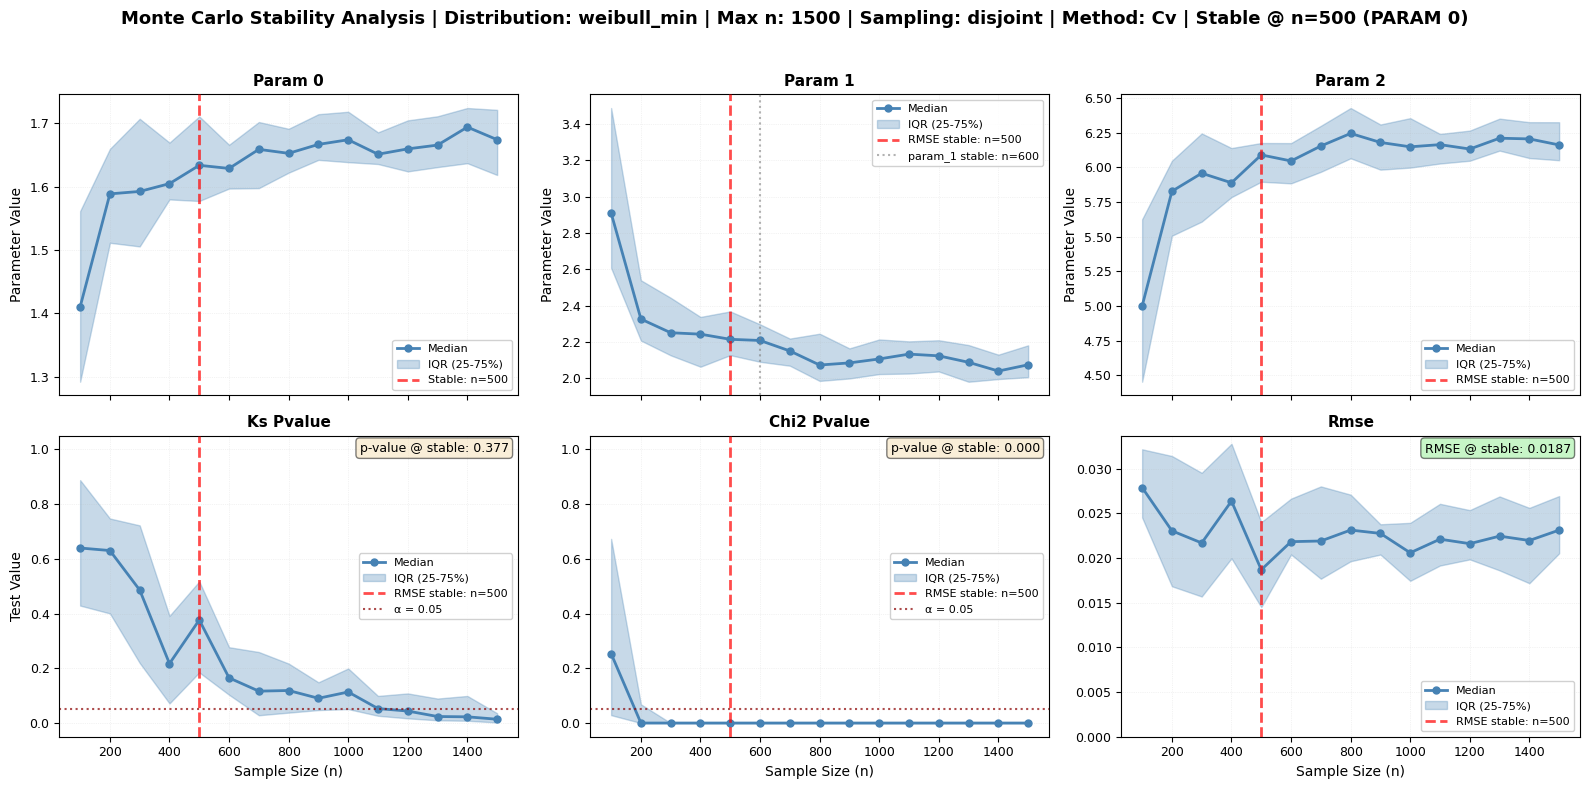

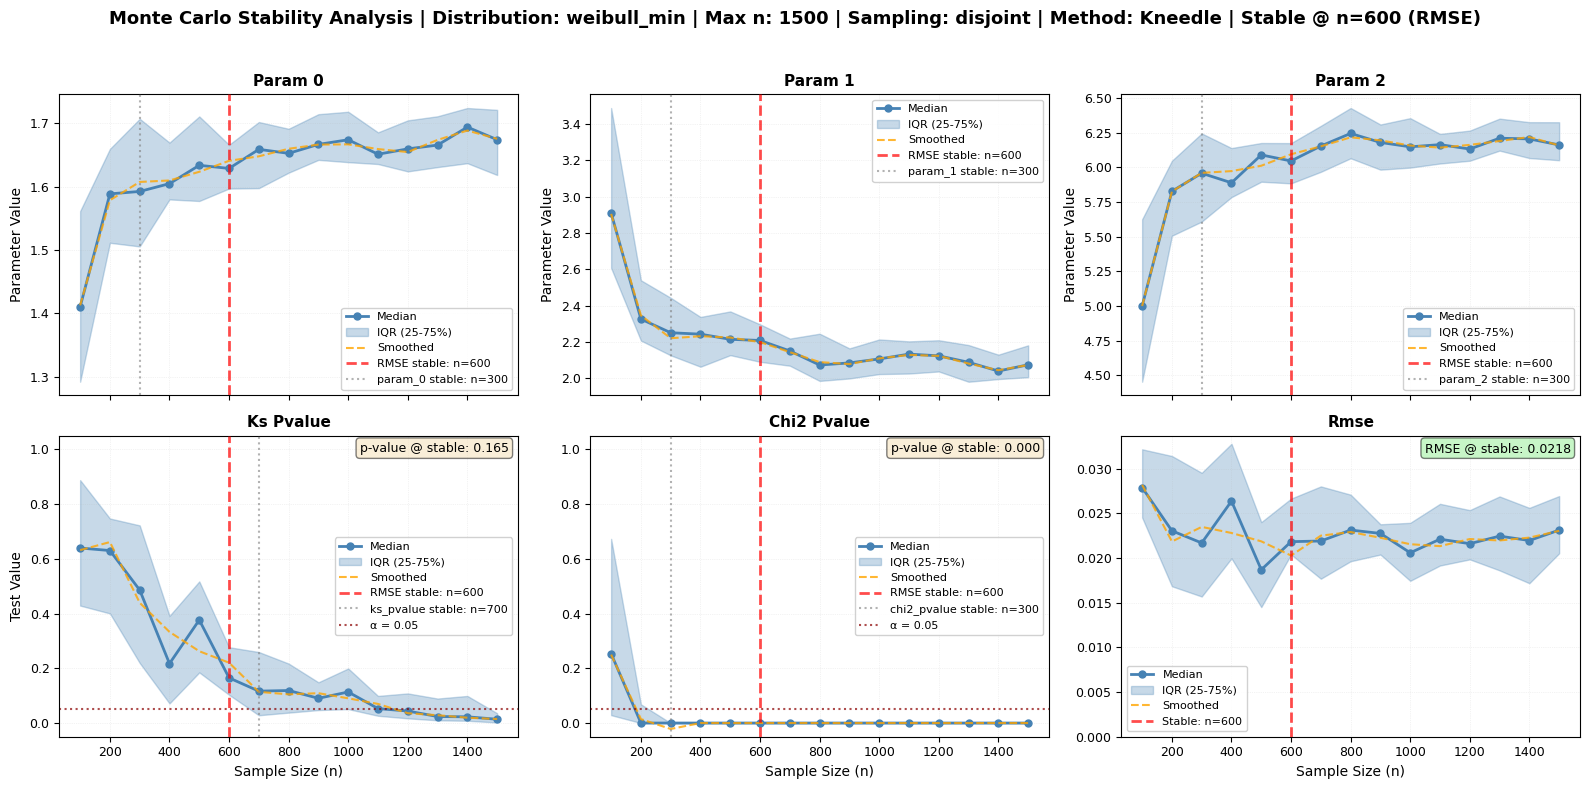

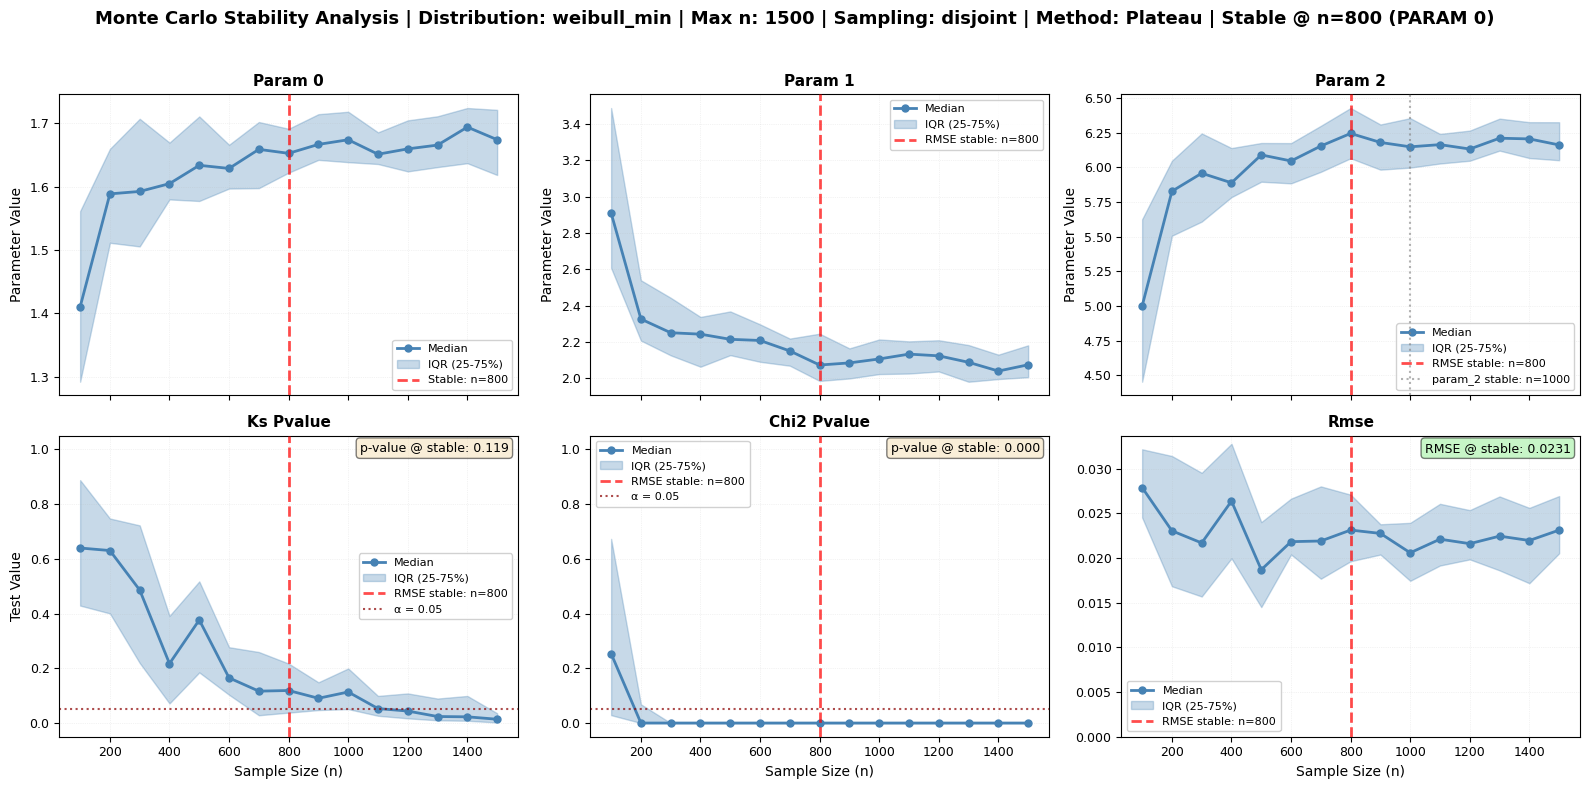

In [15]:
# Test all three stability detection methods
print("Comparing Stability Detection Methods")
print("=" * 80)
print("Running Monte Carlo analysis with different detection methods...")
print("This will take a moment...\n")

# Common parameters for all methods
common_params = {
    'sizes': np.arange(100, 1600, 100),
    'n_repeats': 30,
    'tests': ['ks', 'chi2', 'rmse'],
    'sampling': 'disjoint',
    'seed': 42,
    'plot_type': 'series'
}

# Dictionary to store results
method_results = {}
method_names = {
    'cv': 'Coefficient of Variation',
    'kneedle': 'Kneedle Algorithm',
    'plateau': 'Plateau Detection'
}

# Run analysis with each method
for method_key in ['cv', 'kneedle', 'plateau']:
    print(f"Running with {method_names[method_key]}...")
    
    print(f"\n{method_names[method_key]}:")
    print("-" * 80)
    fig_path = f'mc_method_{method_key}.png'
    
    results = large_adjuster.monte_carlo_fit(
        **common_params,
        stability_method=method_key,
        fig_output_path=fig_path
    )
    
    method_results[method_key] = results
    print(f"  ✓ Completed - Figure saved to: {fig_path}\n")

print("\n" + "=" * 80)
print("FIGURE INTERPRETATION:")
print("=" * 80)
print("\n🔍 What to Look For:")
print("\n1. Red Dashed Vertical Lines**: Detected stability points")
print("   • Shows where each variable stabilizes according to the method")
print("   • Different methods may place these at different locations")
print("\n2. **Orange Dashed Lines** (Kneedle only): Smoothed median curve")
print("   • Helps identify the 'elbow' point more clearly")
print("   • Only visible when using Kneedle method with smoothing enabled")
print("\n3. **RMSE Panel** (Bottom Right):")
print("   • May show a visible bend or plateau")
print("   • Kneedle detects a geometric bend in this curve")
print("   • Look for where the curve flattens out")
print("\n4. **Parameter Panels** (Top Row):")
print("   • Inspect whether estimates converge as n increases")
print("   • Inspect whether the IQR (shaded area) decreases")
print("   • Plateau detection marks consecutive changes below its configured tolerance")
print("\n5. **P-value Panels** (Bottom Left/Center):")
print("   • Red dotted horizontal line at α = 0.05")
print("   • Text box shows p-value at stable point")
print("   • CV is difficult to interpret when their mean is near zero")

In [16]:
# Compare stability points detected by each method
print("STABILITY POINT COMPARISON")
print("=" * 90)
print(f"{'Method':<25} {'RMSE':<15} {'KS p-value':<15} {'Chi² p-value':<15} {'Param 0':<15}")
print("-" * 90)

for method_key, method_name in method_names.items():
    results = method_results[method_key]
    stability = results.attrs['stability_points']
    
    rmse_size = stability.get('rmse', {}).get('size', 'Not detected')
    ks_size = stability.get('ks_pvalue', {}).get('size', 'Not detected')
    chi2_size = stability.get('chi2_pvalue', {}).get('size', 'Not detected')
    param0_size = stability.get('param_0', {}).get('size', 'Not detected')
    
    print(f"{method_name:<25} {str(rmse_size):<15} {str(ks_size):<15} {str(chi2_size):<15} {str(param0_size):<15}")

print("\n" + "=" * 90)
print("PRIMARY STABILITY RESULTS")
print("=" * 90)

for method_key, method_name in method_names.items():
    results = method_results[method_key]
    recommended = results.attrs.get('recommended_size', 'N/A')
    primary = results.attrs.get('primary_metric', 'N/A')
    
    print(f"{method_name:<25} n = {recommended:<10} (based on {primary})")

print("\n💡 KEY OBSERVATIONS:")
print("   • Different methods may detect different stability points")
print("   • RMSE may show a visible bend, but monotonic convergence is not guaranteed")
print("   • CV is difficult to interpret when a metric mean is near zero")
print("   • Kneedle results depend on the tested grid and smoothing")
print("   • Plateau results depend on tolerance and consecutive-point settings")

STABILITY POINT COMPARISON
Method                    RMSE            KS p-value      Chi² p-value    Param 0        
------------------------------------------------------------------------------------------
Coefficient of Variation  None            None            None            500            
Kneedle Algorithm         600             700             300             300            
Plateau Detection         None            None            None            800            

PRIMARY STABILITY RESULTS
Coefficient of Variation  n = 500        (based on param_0)
Kneedle Algorithm         n = 600        (based on rmse)
Plateau Detection         n = 800        (based on param_0)

💡 KEY OBSERVATIONS:
   • Different methods may detect different stability points
   • RMSE may show a visible bend, but monotonic convergence is not guaranteed
   • CV is difficult to interpret when a metric mean is near zero
   • Kneedle results depend on the tested grid and smoothing
   • Plateau results depend on

### Understanding Each Method

#### 1. Coefficient of Variation (CV) Method

**How it works:**
- Calculates std/mean across repeats for each sample size
- Looks for when CV stays consistently below 10% threshold
- Uses a sliding window to ensure stability is sustained

**When to consider it:**
- Metrics with a nonzero mean for which relative variability is meaningful
- Cases where the threshold and window can be checked in a sensitivity analysis
- Use caution with bounded metrics and means near zero, including some p-value trajectories

**Parameters:**
- `window_size`: Number of consecutive sizes that must be stable (default: len(sizes)//4)
- `cv_threshold`: Maximum acceptable CV (default: 0.1 = 10%)

#### 2. Kneedle Algorithm

**How it works:**
- Based on Satopää et al. (2011) paper
- Normalizes curve to [0,1] range
- Finds maximum distance between curve and reference line (the "elbow")
- Optionally smooths curve first for clearer detection

**When to consider it:**
- RMSE (decreasing curves with clear elbow)
- Converging parameters
- When you want to find the "point of diminishing returns"

**Parameters:**
- `smooth`: Enable curve smoothing (default: True)
- `smoothing_method`: 'savgol' (default) or 'spline'

**Visual indicator:**
- Orange dashed line shows smoothed curve in figures

#### 3. Plateau Detection

**How it works:**
- Uses relative gain heuristic: Δᵢ = |y(i-1) - y(i)| / |y(i-1)|
- Detects when improvement becomes negligible
- Requires several consecutive points below threshold

**When to consider it:**
- Converging parameters
- Metrics with clear plateau behavior
- When a domain-informed tolerance defines a sufficiently small relative change

**Parameters:**
- `consecutive_points`: L parameter - points that must satisfy criterion (default: 3)
- `relative_tolerance`: Δ parameter - maximum acceptable change (default: 0.01 = 1%)

In [17]:
# Demonstrate method-specific parameters
print("TESTING METHOD-SPECIFIC PARAMETERS")
print("=" * 80)
print("\nLet's see how parameter tuning affects detection...\n")

# Test Kneedle with different smoothing methods
print("1. Kneedle with different smoothing:")
print("-" * 40)

for smooth_method in ['savgol', 'spline']:
    results_smooth = large_adjuster.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='kneedle',
        smooth=True,
        smoothing_method=smooth_method,
        seed=42
    )
    
    rmse_stable = results_smooth.attrs['stability_points']['rmse']['size']
    print(f"  {smooth_method:8s}: RMSE stabilizes at n = {rmse_stable}")

# Test Plateau with different tolerances
print("\n2. Plateau with different relative tolerances:")
print("-" * 40)

for tol in [0.005, 0.01, 0.02]:
    results_plateau = large_adjuster.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='plateau',
        relative_tolerance=tol,
        consecutive_points=3,
        seed=42
    )
    
    rmse_stable = results_plateau.attrs['stability_points']['rmse'].get('size', 'Not detected')
    print(f"  Δ = {tol:.3f} (tol = {tol*100:.1f}%): RMSE stabilizes at n = {rmse_stable}")

# Test CV with different thresholds
print("\n3. CV with different thresholds:")
print("-" * 40)

for cv_thresh in [0.05, 0.10, 0.15]:
    results_cv = large_adjuster.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='cv',
        cv_threshold=cv_thresh,
        seed=42
    )
    
    rmse_stable = results_cv.attrs['stability_points']['rmse'].get('size', 'Not detected')
    print(f"  CV < {cv_thresh:.2f} ({cv_thresh*100:.0f}%): RMSE stabilizes at n = {rmse_stable}")

print("\n💡 KEY INSIGHTS:")
print("   • Stricter thresholds → Later detection (more conservative)")
print("   • Looser thresholds → Earlier detection (more aggressive)")
print("   • Savgol smoothing preserves features better than spline")
print("   • Choose parameters based on your application's needs")

TESTING METHOD-SPECIFIC PARAMETERS

Let's see how parameter tuning affects detection...

1. Kneedle with different smoothing:
----------------------------------------
  savgol  : RMSE stabilizes at n = 800
  spline  : RMSE stabilizes at n = 1500

2. Plateau with different relative tolerances:
----------------------------------------
  Δ = 0.005 (tol = 0.5%): RMSE stabilizes at n = None
  Δ = 0.010 (tol = 1.0%): RMSE stabilizes at n = None
  Δ = 0.020 (tol = 2.0%): RMSE stabilizes at n = None

3. CV with different thresholds:
----------------------------------------
  CV < 0.05 (5%): RMSE stabilizes at n = None
  CV < 0.10 (10%): RMSE stabilizes at n = None
  CV < 0.15 (15%): RMSE stabilizes at n = 2500

💡 KEY INSIGHTS:
   • Stricter thresholds → Later detection (more conservative)
   • Looser thresholds → Earlier detection (more aggressive)
   • Savgol smoothing preserves features better than spline
   • Choose parameters based on your application's needs


### Method Selection Guide

Use this table to choose methods worth comparing for your analysis:

| Signal | Method to consider | Limitation to check |
|------------|-------------------|-----|
| **RMSE with a visible bend** | `kneedle` | Grid and smoothing sensitivity |
| **Parameters approaching a plateau** | `kneedle` or `plateau` | Bend or tolerance must be meaningful |
| **Relative variability** | `cv` | Mean must remain sufficiently far from zero |
| **Small consecutive changes** | `plateau` | Tolerance and window sensitivity |
| **Mixed metrics** | Compare methods | Metrics may require different interpretations |



PRACTICAL EXAMPLE: Using Kneedle for RMSE Analysis

Inspect the result and its sensitivity to the configuration.

RESULTS:
--------------------------------------------------------------------------------
Primary stability result: n = 400
Based on: RMSE

Stability points by metric:
  rmse           : n =        400 (method: kneedle)
  ks_pvalue      : n =       1200 (method: kneedle)
  chi2_pvalue    : n =        400 (method: kneedle)
  param_0        : n =        400 (method: kneedle)

Quality at stable point (n = 400):
  RMSE:        0.021654
  KS p-value:  0.4281
  χ² p-value:  0.0000

Figure saved to: final_stability_analysis.png



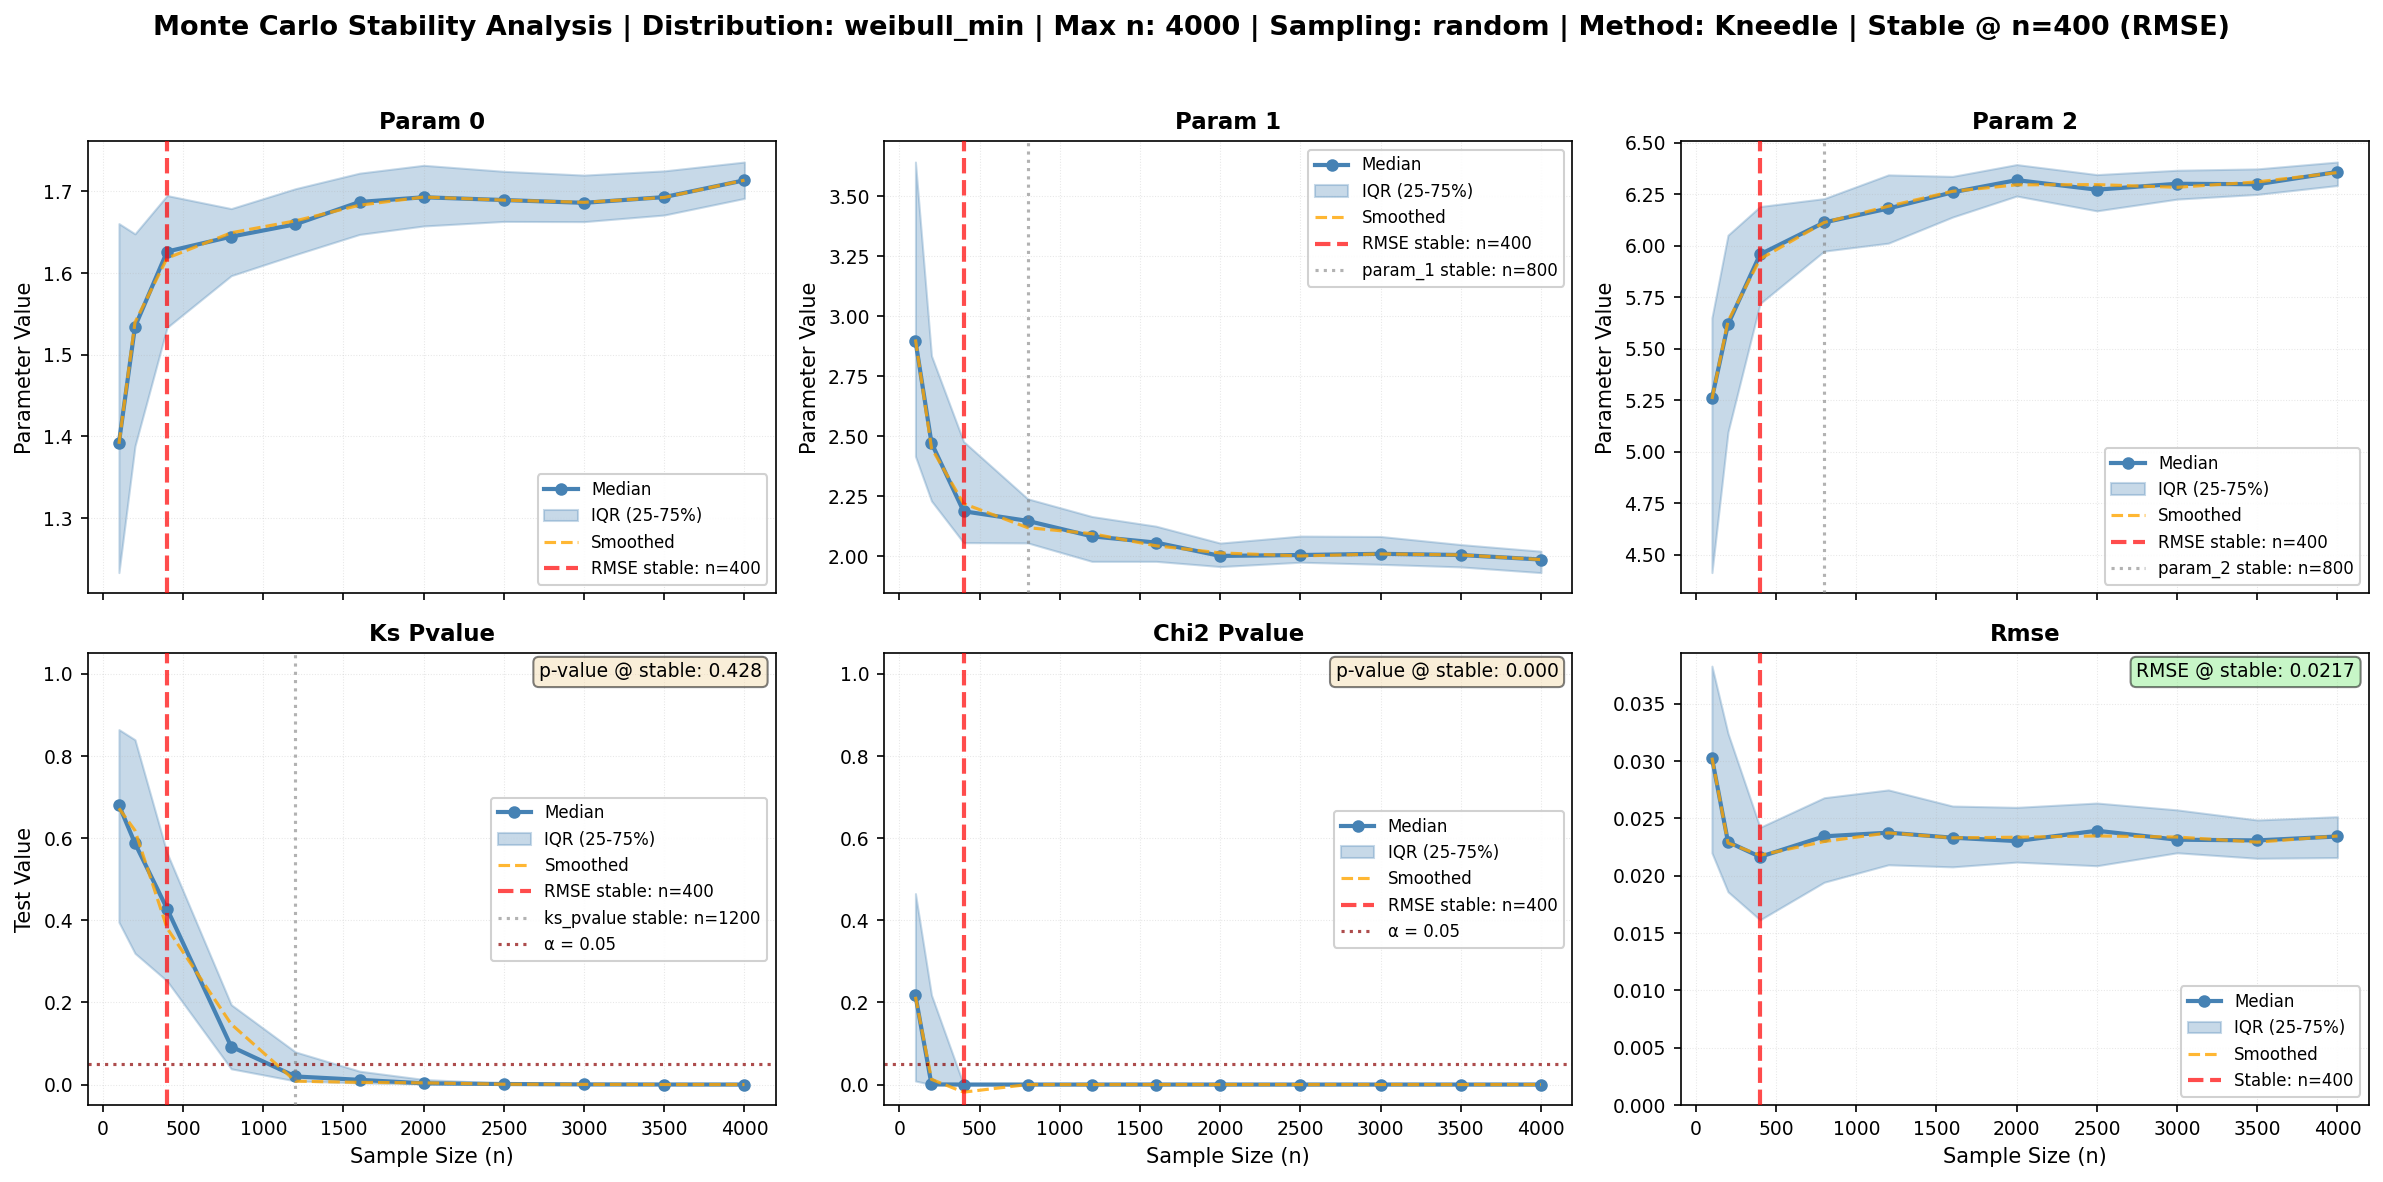


✅ SUCCESS!
   This figure shows:
   • Orange dashed lines: Smoothed curves (Kneedle's preprocessing)
   • Red vertical lines: Detected stability points
   • Informative title: Distribution, max n, and primary stability result
   • Quality metrics: P-values and RMSE at the stable point

   Check sensitivity before using n = 400 in the application.


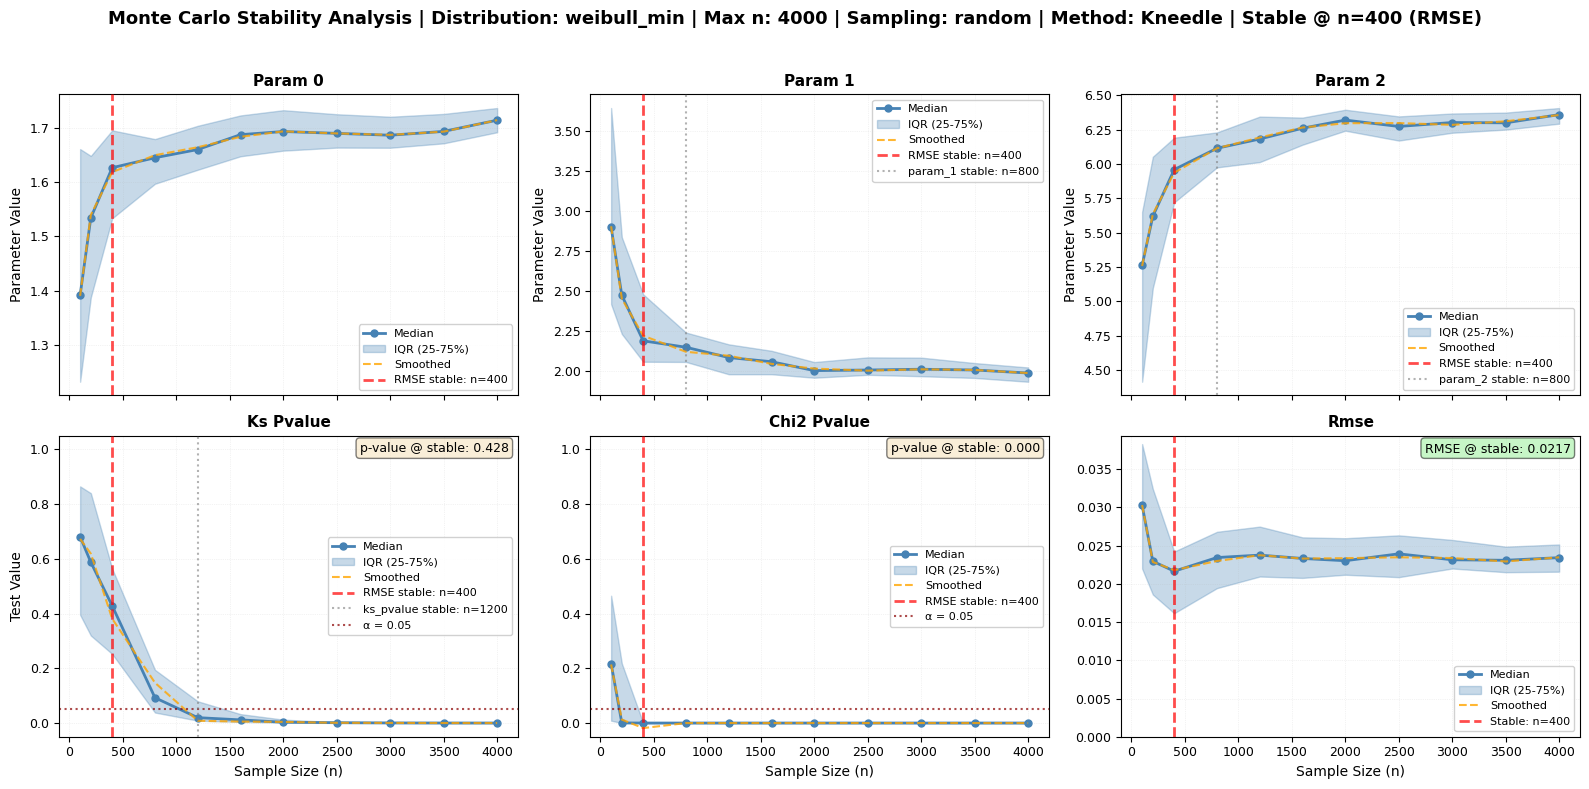

In [18]:
from IPython.display import Image, display 

# Practical example: Apply Kneedle to the RMSE curve
print("PRACTICAL EXAMPLE: Using Kneedle for RMSE Analysis")
print("=" * 80)
print("\nInspect the result and its sensitivity to the configuration.\n")

# Run with Kneedle method
final_results = large_adjuster.monte_carlo_fit(
    sizes=[100, 200, 400, 800, 1200, 1600, 2000, 2500, 3000, 3500, 4000],
    n_repeats=50,
    tests=['ks', 'chi2', 'rmse'],
    stability_method='kneedle',
    smooth=True,
    smoothing_method='savgol',
    sampling='random',
    seed=42,
    fig_output_path='final_stability_analysis.png',
    plot_type='series'
)

# Extract key information
recommended_n = final_results.attrs['recommended_size']
primary_metric = final_results.attrs['primary_metric']
stability_points = final_results.attrs['stability_points']

print("RESULTS:")
print("-" * 80)
print(f"Primary stability result: n = {recommended_n}")
print(f"Based on: {primary_metric.upper()}")
print(f"\nStability points by metric:")

for metric in ['rmse', 'ks_pvalue', 'chi2_pvalue', 'param_0']:
    if metric in stability_points:
        info = stability_points[metric]
        size = info.get('size', 'Not detected')
        method = info.get('method', 'N/A')
        print(f"  {metric:15s}: n = {size:10} (method: {method})")

# Display quality metrics at stable point
print(f"\nQuality at stable point (n = {recommended_n}):")
if final_results.attrs.get('stable_rmse') is not None:
    print(f"  RMSE:        {final_results.attrs['stable_rmse']:.6f}")
if final_results.attrs.get('stable_pvalue_ks') is not None:
    print(f"  KS p-value:  {final_results.attrs['stable_pvalue_ks']:.4f}")
if final_results.attrs.get('stable_pvalue_chi2') is not None:
    print(f"  χ² p-value:  {final_results.attrs['stable_pvalue_chi2']:.4f}")

print(f"\nFigure saved to: {final_results.attrs['figure_path']}")

# Display the final figure
print("\n" + "=" * 80)
display(Image(filename=final_results.attrs['figure_path']))

print("\n✅ SUCCESS!")
print("   This figure shows:")
print("   • Orange dashed lines: Smoothed curves (Kneedle's preprocessing)")
print("   • Red vertical lines: Detected stability points")
print("   • Informative title: Distribution, max n, and primary stability result")
print("   • Quality metrics: P-values and RMSE at the stable point")
print(f"\n   Check sensitivity before using n = {recommended_n} in the application.")

## Summary and Best Practices

### Key Points:

1. **Data Loading**: Use `ma.read_data()` to create a `DataProcessor`
2. **Distribution Fitting**: Use `.fit_distribution(distribution_name)` 
3. **Direct Method Access**: All SciPy methods available directly (pdf, cdf, ppf, etc.)
4. **Smart Defaults**: Methods like `pdf()` and `cdf()` use original data when no input provided
5. **Goodness-of-Fit**: Use `.goodness_of_fit()` with 'ks', 'chi2', or 'rmse'
6. **Bin Selection**: Chi-square test supports multiple binning methods ('doane', 'sturges', etc.)
7. **Constraints**: Pass fitting constraints as keyword arguments (e.g., `floc=0`)
8. **Stability Analysis**: Use `monte_carlo_fit()` with automatic figure generation
9. **Large Sample Effects**: Inspect how test statistics, p-values, and discrepancy measures evolve with sample size
10. **Stability Interpretation**: Treat detected points as conditional on the grid, repeats, metric, and detector

### Important Considerations:

- **RMSE**: MagicA's empirically recommended primary stability signal; it summarizes distance between the empirical and fitted CDFs
  - It produced a clearer stability point than the p-value curves in the tests that motivated the method
  - It does not replace tail checks or penalize model complexity
  - AIC/BIC are not Monte Carlo outputs in MagicA, and their stability was not evaluated here
  
- **Chi-square binning**: Different methods can significantly affect results - choose appropriately

- **Large samples**: Tests can detect increasingly small model departures; no universal cutoff applies

- **CPS method**: Lets you compare how statistical signals and discrepancy measures change with sample size

- **Sampling strategy**: 
  - 'random': repeated draws without replacement within each draw
  - 'bootstrap': with replacement; uncertainty interpretation depends on the sampling assumptions
  - 'disjoint': non-overlapping within a shuffle and does not preserve temporal/spatial order

- **Reproducibility**: Always set random seeds for Monte Carlo analyses

- **Automatic plotting**: Use `fig_output_path` parameter to generate summary figures

- **Plot types**: 'series' shows medians with IQR, 'boxplots' shows distribution per size

### Monte Carlo Analysis Features:

The `monte_carlo_fit()` method provides:

1. **Automatic figure generation**: Set `fig_output_path` to save a 2x3 summary plot
2. **Stability detection**: Automatically identifies where parameters/tests stabilize
3. **Multiple tests**: Run KS, Chi-square, and **RMSE** tests simultaneously
4. **Flexible sampling**: Choose between random, bootstrap, or disjoint strategies
5. **Parameter tracking**: Monitor how all distribution parameters evolve with sample size
6. **Primary result**: Get a detector-dependent stability point or the largest-size fallback

### Interpreting Stability Detection:

**Compare the available signals:**

1. RMSE measures empirical-CDF distance, while test statistics and p-values answer different questions
2. A visible bend or plateau may support a stability interpretation
3. Check sensitivity to sample-size grid, repeats, thresholds, and smoothing
4. If `primary_metric` is `max_size`, no stability point was detected

**Visual cue in plots:**
- Look at bottom-right panel (RMSE)
- Find where curve flattens (red dashed line)
- Treat the marked point as a result of the configured detector

For automatic distribution selection, see the AutoFitter tutorial!